# 05 — Computational Benchmarks

This notebook quantifies the computational cost of the direct
frequency-domain method after the numerical validation performed in
Notebooks 03 and 04.

The benchmarks address three questions:

1. How does direct frequency-domain evaluation compare with explicit
   time-domain propagation followed by a two-dimensional Fourier
   transform?

2. What is the additional computational cost of finite-width
   Liouvillian pulse dressing relative to the impulsive and
   short-pulse treatments?

3. How does the computational cost scale with the requested spectral
   resolution?

The coupled thermal dimer used in the previous validation notebooks is
retained so that the benchmark compares methods rather than physical
models.

Unless otherwise stated, timing comparisons use the nonrephasing
branch only. The rephasing branch has the same numerical structure and
would provide redundant performance information.

In [35]:
# ------------------------------------------------------------
# Imports and repository setup
# ------------------------------------------------------------

import sys
import gc
from pathlib import Path
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm

repo_root = Path.cwd().parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.dimer_model import (
    build_dimer,
    stationary_state,
    vec,
    unvec,
)


# ------------------------------------------------------------
# Figure directory
# ------------------------------------------------------------

figure_dir = (
    repo_root
    / "figures"
    / "05_computational_benchmarks"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Same dimer used in the validation notebooks
# ------------------------------------------------------------

model = build_dimer()

L = model["L_super"]
V = model["V"]
mu = model["mu"]

d = mu.shape[0]
N_L = d**2

rho_ss = stationary_state(
    L,
    d,
)

rho_ss_vec = vec(
    rho_ss
)

mu_bra = vec(mu).conj()

I_L = np.eye(
    N_L,
    dtype=complex,
)


print("Hilbert dimension =", d)
print("Liouville dimension =", N_L)
print("L shape =", L.shape)
print("V shape =", V.shape)
print()
print(
    "stationarity error =",
    np.linalg.norm(
        L @ rho_ss_vec
    ),
)

Hilbert dimension = 4
Liouville dimension = 16
L shape = (16, 16)
V shape = (16, 16)

stationarity error = 2.4568429163371704e-18


In [36]:
# ------------------------------------------------------------
# Timing utility
# ------------------------------------------------------------

def benchmark_function(
    func,
    *args,
    repeats=5,
    warmup=1,
    **kwargs,
):
    """
    Time one numerical function.

    Returns
    -------
    result :
        Output from the final timed evaluation.

    median_time :
        Median wall-clock time over all repeats.

    times :
        Individual timing measurements.
    """

    # Warm-up calls
    for _ in range(warmup):
        func(
            *args,
            **kwargs,
        )

    times = []
    result = None

    for _ in range(repeats):

        gc.collect()

        t0 = perf_counter()

        result = func(
            *args,
            **kwargs,
        )

        t1 = perf_counter()

        times.append(
            t1 - t0
        )

    times = np.asarray(
        times,
        dtype=float,
    )

    return (
        result,
        np.median(times),
        times,
    )

In [37]:
# ------------------------------------------------------------
# Timing utility sanity check
# ------------------------------------------------------------

rng = np.random.default_rng(1234)

A_test = (
    rng.normal(size=(200, 200))
    +
    1j * rng.normal(size=(200, 200))
)

B_test = (
    rng.normal(size=(200, 200))
    +
    1j * rng.normal(size=(200, 200))
)


def test_matrix_product():
    return A_test @ B_test


_, median_test, times_test = benchmark_function(
    test_matrix_product,
    repeats=5,
    warmup=1,
)

print(
    "individual times [s] =",
    times_test,
)

print(
    "median time [s] =",
    median_test,
)

individual times [s] = [0.0002765  0.0002905  0.000198   0.00016983 0.00026654]
median time [s] = 0.0002665419888217002


## 1. Frequency-domain versus explicit time-domain evaluation

We first compare two numerically equivalent calculations of the
impulsive nonrephasing RWA response.

The direct frequency-domain calculation evaluates

$$
M_{\mathrm{NR}}^{(3)}
(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V_\uparrow
e^{\mathcal{L}T}
V_\downarrow
G_\eta(\omega_1)
V_\uparrow
|\rho_0\rangle\rangle .
$$

The time-domain calculation instead constructs

$$
R_{\mathrm{NR}}^{(3)}
(t_3,T,t_1)
=
\langle\!\langle\mu|
e^{\mathcal{L}t_3}
V_\uparrow
e^{\mathcal{L}T}
V_\downarrow
e^{\mathcal{L}t_1}
V_\uparrow
|\rho_0\rangle\rangle
$$

on a two-dimensional time grid and subsequently performs the damped
two-dimensional Fourier transform.

The benchmark records separately:

- direct frequency-domain evaluation time;
- time-domain propagation time;
- two-dimensional transform time;
- total time-domain cost.

In [38]:
# ------------------------------------------------------------
# RWA interaction operators
# ------------------------------------------------------------

hbar = model["hbar"]
I4 = model["I4"]

mu_up = (
    model["sigma_a_plus"]
    + model["sigma_b_plus"]
)

mu_down = (
    model["sigma_a_minus"]
    + model["sigma_b_minus"]
)

V_up = (
    1j / hbar
    * (
        np.kron(I4, mu_up)
        - np.kron(mu_up.T, I4)
    )
)

V_down = (
    1j / hbar
    * (
        np.kron(I4, mu_down)
        - np.kron(mu_down.T, I4)
    )
)


print(
    "||V - (V_up + V_down)|| =",
    np.linalg.norm(
        V - (V_up + V_down)
    ),
)


# ------------------------------------------------------------
# Initial state
#
# Use the ground state so this benchmark can later be repeated
# directly with the QuDPy pathway implementation.
# ------------------------------------------------------------

rho0 = model["rho0"]
rho0_vec = vec(rho0)


# ------------------------------------------------------------
# Benchmark parameters
# ------------------------------------------------------------

eta_bench = 0.02
T_bench = 5.0

tmax_bench = 100.0
dt_bench = 0.25

t1_bench = np.arange(
    0.0,
    tmax_bench + 0.5 * dt_bench,
    dt_bench,
)

t3_bench = t1_bench.copy()

Nw_bench = 81

omega1_bench = np.linspace(
    0.6,
    1.4,
    Nw_bench,
)

omega3_bench = np.linspace(
    0.6,
    1.4,
    Nw_bench,
)


print()
print("Benchmark parameters")
print("--------------------")
print("T =", T_bench)
print("eta =", eta_bench)
print("tmax =", tmax_bench)
print("dt =", dt_bench)
print("Nt1 =", len(t1_bench))
print("Nt3 =", len(t3_bench))
print("Nw1 =", len(omega1_bench))
print("Nw3 =", len(omega3_bench))

||V - (V_up + V_down)|| = 0.0

Benchmark parameters
--------------------
T = 5.0
eta = 0.02
tmax = 100.0
dt = 0.25
Nt1 = 401
Nt3 = 401
Nw1 = 81
Nw3 = 81


In [39]:
# ------------------------------------------------------------
# Direct frequency-domain NR spectrum
# ------------------------------------------------------------

def direct_NR_frequency_domain(
    omega1,
    omega3,
    T,
    eta,
):
    """
    Direct impulsive NR RWA spectrum.

    Output shape:
        (len(omega3), len(omega1))
    """

    U_T = expm(
        L * T
    )

    b1 = (
        V_up
        @ rho0_vec
    )

    # --------------------------------------------------------
    # First resolvent:
    # one RHS for each omega1
    # --------------------------------------------------------

    X1 = np.empty(
        (
            N_L,
            len(omega1),
        ),
        dtype=complex,
    )

    for j, w1 in enumerate(omega1):

        A1 = (
            (eta - 1j * w1) * I_L
            - L
        )

        X1[:, j] = np.linalg.solve(
            A1,
            b1,
        )

    # --------------------------------------------------------
    # Second interaction, waiting time, third interaction
    # --------------------------------------------------------

    Y = (
        V_up
        @ (
            U_T
            @ (
                V_down
                @ X1
            )
        )
    )

    # --------------------------------------------------------
    # Detection resolvent
    #
    # Each solve uses all omega1 columns as simultaneous RHSs.
    # --------------------------------------------------------

    P = np.empty(
        (
            len(omega3),
            len(omega1),
        ),
        dtype=complex,
    )

    for i, w3 in enumerate(omega3):

        A3 = (
            (eta - 1j * w3) * I_L
            - L
        )

        Z = np.linalg.solve(
            A3,
            Y,
        )

        P[i, :] = (
            mu_bra
            @ Z
        )

    return P

In [40]:
# ------------------------------------------------------------
# Explicit time-domain NR response
# ------------------------------------------------------------

def NR_time_domain_response(
    t1,
    t3,
    T,
):
    """
    Explicit impulsive NR RWA response

        R(t3, T, t1)

    using recursive time stepping with exact expm(L dt)
    propagators.
    """

    if len(t1) < 2 or len(t3) < 2:
        raise ValueError(
            "Time grids must contain at least two points."
        )

    dt1 = t1[1] - t1[0]
    dt3 = t3[1] - t3[0]

    U1 = expm(
        L * dt1
    )

    U3 = expm(
        L * dt3
    )

    U_T = expm(
        L * T
    )

    # --------------------------------------------------------
    # First interaction
    # --------------------------------------------------------

    x = (
        V_up
        @ rho0_vec
    )

    # All t1 states
    X1 = np.empty(
        (
            N_L,
            len(t1),
        ),
        dtype=complex,
    )

    X1[:, 0] = x

    for j in range(
        1,
        len(t1),
    ):

        X1[:, j] = (
            U1
            @ X1[:, j - 1]
        )

    # --------------------------------------------------------
    # Second interaction -> waiting -> third interaction
    # --------------------------------------------------------

    B = (
        V_up
        @ (
            U_T
            @ (
                V_down
                @ X1
            )
        )
    )

    # --------------------------------------------------------
    # Detection-time propagation
    # --------------------------------------------------------

    R = np.empty(
        (
            len(t3),
            len(t1),
        ),
        dtype=complex,
    )

    R[0, :] = (
        mu_bra
        @ B
    )

    B_current = B.copy()

    for i in range(
        1,
        len(t3),
    ):

        B_current = (
            U3
            @ B_current
        )

        R[i, :] = (
            mu_bra
            @ B_current
        )

    return R

In [41]:
# ------------------------------------------------------------
# Damped two-dimensional Fourier transform
# ------------------------------------------------------------

def damped_2D_transform(
    R,
    t1,
    t3,
    omega1,
    omega3,
    eta,
):
    """
    Numerical trapezoidal evaluation of

        integral dt3 dt1
        exp[(i w3 - eta)t3]
        exp[(i w1 - eta)t1]
        R(t3,t1)
    """

    dt1 = t1[1] - t1[0]
    dt3 = t3[1] - t3[0]

    # Trapezoidal weights
    weights1 = np.ones(
        len(t1)
    )

    weights3 = np.ones(
        len(t3)
    )

    weights1[[0, -1]] = 0.5
    weights3[[0, -1]] = 0.5

    weights1 *= dt1
    weights3 *= dt3

    K1 = (
        np.exp(
            (
                1j * omega1[:, None]
                - eta
            )
            * t1[None, :]
        )
        * weights1[None, :]
    )

    K3 = (
        np.exp(
            (
                1j * omega3[:, None]
                - eta
            )
            * t3[None, :]
        )
        * weights3[None, :]
    )

    return (
        K3
        @ R
        @ K1.T
    )

In [42]:
# ------------------------------------------------------------
# Correctness check
# ------------------------------------------------------------

P_FD_check = direct_NR_frequency_domain(
    omega1_bench,
    omega3_bench,
    T_bench,
    eta_bench,
)

R_TD_check = NR_time_domain_response(
    t1_bench,
    t3_bench,
    T_bench,
)

P_TD_check = damped_2D_transform(
    R_TD_check,
    t1_bench,
    t3_bench,
    omega1_bench,
    omega3_bench,
    eta_bench,
)


error_check = (
    np.linalg.norm(
        P_TD_check
        - P_FD_check
    )
    /
    np.linalg.norm(
        P_FD_check
    )
)


print(
    "TD vs direct-FD relative Frobenius error =",
    error_check,
)

print()
print(
    "||P_FD|| =",
    np.linalg.norm(P_FD_check),
)

print(
    "||P_TD|| =",
    np.linalg.norm(P_TD_check),
)

TD vs direct-FD relative Frobenius error = 0.010794817497763948

||P_FD|| = 24872.12253712726
||P_TD|| = 24869.312043477563


In [43]:
# ------------------------------------------------------------
# Benchmark 1 timing
# ------------------------------------------------------------

# Direct frequency domain
P_FD_bench, t_FD, times_FD = benchmark_function(
    direct_NR_frequency_domain,
    omega1_bench,
    omega3_bench,
    T_bench,
    eta_bench,
    repeats=5,
    warmup=1,
)


# Explicit time-domain propagation
R_TD_bench, t_TD_prop, times_TD_prop = benchmark_function(
    NR_time_domain_response,
    t1_bench,
    t3_bench,
    T_bench,
    repeats=5,
    warmup=1,
)


# 2D transform only
P_TD_bench, t_TD_fft, times_TD_fft = benchmark_function(
    damped_2D_transform,
    R_TD_bench,
    t1_bench,
    t3_bench,
    omega1_bench,
    omega3_bench,
    eta_bench,
    repeats=5,
    warmup=1,
)


t_TD_total = (
    t_TD_prop
    + t_TD_fft
)

speedup_FD = (
    t_TD_total
    / t_FD
)


print("BENCHMARK 1")
print("-----------")
print()

print(
    f"Direct FD median       = {t_FD:.6f} s"
)

print(
    f"TD propagation median  = {t_TD_prop:.6f} s"
)

print(
    f"2D transform median    = {t_TD_fft:.6f} s"
)

print(
    f"TD total               = {t_TD_total:.6f} s"
)

print()

print(
    f"TD / FD speed ratio    = {speedup_FD:.3f} x"
)

print()

print(
    "FD individual timings =",
    times_FD,
)

print(
    "TD propagation timings =",
    times_TD_prop,
)

print(
    "Transform timings       =",
    times_TD_fft,
)

BENCHMARK 1
-----------

Direct FD median       = 0.001519 s
TD propagation median  = 0.003877 s
2D transform median    = 0.001121 s
TD total               = 0.004998 s

TD / FD speed ratio    = 3.290 x

FD individual timings = [0.00183067 0.00177846 0.00151917 0.00139229 0.00138683]
TD propagation timings = [0.00369496 0.00387675 0.0038995  0.00384267 0.00393592]
Transform timings       = [0.00120113 0.00123892 0.00103225 0.00106392 0.00112075]


### Batched timing refinement

Because individual frequency-domain evaluations require only a few
milliseconds for the present 16-dimensional Liouville space, single-call
wall-clock measurements are sensitive to operating-system scheduling,
BLAS initialization, and cache effects.

For the reported benchmark, each timing sample therefore contains
multiple identical evaluations. The measured batch time is divided by
the number of evaluations to obtain a per-spectrum runtime.

In [44]:
# ------------------------------------------------------------
# Batched timing utility for short calculations
# ------------------------------------------------------------

def benchmark_batched(
    func,
    *args,
    batch_size=20,
    repeats=7,
    warmup=2,
    **kwargs,
):
    """
    Measure short numerical functions more robustly by executing
    several evaluations inside each timed batch.

    Returns
    -------
    result :
        Result of the final function evaluation.

    median_per_call :
        Median wall-clock time per function evaluation.

    per_call_times :
        Per-evaluation time from every timed batch.
    """

    # Warm-up
    for _ in range(warmup):
        func(
            *args,
            **kwargs,
        )

    per_call_times = []
    result = None

    for _ in range(repeats):

        gc.collect()

        t0 = perf_counter()

        for _ in range(batch_size):
            result = func(
                *args,
                **kwargs,
            )

        t1 = perf_counter()

        per_call_times.append(
            (t1 - t0) / batch_size
        )

    per_call_times = np.asarray(
        per_call_times,
        dtype=float,
    )

    return (
        result,
        np.median(per_call_times),
        per_call_times,
    )

In [45]:
# ------------------------------------------------------------
# Refined Benchmark 1
# ------------------------------------------------------------

P_FD_batch, t_FD_batch, times_FD_batch = benchmark_batched(
    direct_NR_frequency_domain,
    omega1_bench,
    omega3_bench,
    T_bench,
    eta_bench,
    batch_size=50,
    repeats=7,
    warmup=2,
)


R_TD_batch, t_TD_prop_batch, times_TD_prop_batch = benchmark_batched(
    NR_time_domain_response,
    t1_bench,
    t3_bench,
    T_bench,
    batch_size=10,
    repeats=7,
    warmup=2,
)


P_TD_batch, t_TD_fft_batch, times_TD_fft_batch = benchmark_batched(
    damped_2D_transform,
    R_TD_batch,
    t1_bench,
    t3_bench,
    omega1_bench,
    omega3_bench,
    eta_bench,
    batch_size=50,
    repeats=7,
    warmup=2,
)


t_TD_total_batch = (
    t_TD_prop_batch
    + t_TD_fft_batch
)

speedup_batch = (
    t_TD_total_batch
    / t_FD_batch
)


print("REFINED BENCHMARK 1")
print("-------------------")
print()

print(
    f"Direct FD           = {t_FD_batch:.6f} s"
)

print(
    f"TD propagation      = {t_TD_prop_batch:.6f} s"
)

print(
    f"2D transform        = {t_TD_fft_batch:.6f} s"
)

print(
    f"TD total            = {t_TD_total_batch:.6f} s"
)

print()

print(
    f"TD / FD speed ratio = {speedup_batch:.3f} x"
)

print()

print(
    "FD batched timings =",
    times_FD_batch,
)

print(
    "TD batched timings =",
    times_TD_prop_batch,
)

print(
    "FT batched timings =",
    times_TD_fft_batch,
)

REFINED BENCHMARK 1
-------------------

Direct FD           = 0.001304 s
TD propagation      = 0.003718 s
2D transform        = 0.000954 s
TD total            = 0.004672 s

TD / FD speed ratio = 3.581 x

FD batched timings = [0.00146582 0.00130701 0.00129525 0.00130179 0.0013052  0.00130438
 0.00130266]
TD batched timings = [0.0037226  0.00371795 0.00369396 0.00375047 0.00370764 0.00372561
 0.00369518]
FT batched timings = [0.00097309 0.00093965 0.00097369 0.0009425  0.00094442 0.00095368
 0.00095362]


## 2. Computational cost of finite-pulse dressing

We next quantify the additional numerical cost introduced by the
operator-valued finite-pulse factors.

Three calculations are compared on the same two-dimensional frequency
grid:

1. the impulsive RWA response;
2. the short-pulse RWA response, in which scalar Gaussian pulse spectra
   multiply the impulsive molecular response;
3. the finite-width full-interaction response, in which the
   Liouvillian-dressed operators \(F_1\), \(F_2\), and \(F_3\) are
   evaluated explicitly.

This benchmark measures the computational price of retaining molecular
evolution during the pulse duration.

In [46]:
# ------------------------------------------------------------
# Finite-pulse parameters
# ------------------------------------------------------------

sigma_pulse = 1.25

omega_a = model["omega_a"]
omega_b = model["omega_b"]
J = model["J"]

Omega_plus = (
    0.5 * (omega_a + omega_b)
    + np.sqrt(
        ((omega_a - omega_b) / 2.0)**2
        + J**2
    )
)

omega_L1 = Omega_plus
omega_L2 = Omega_plus
omega_L3 = Omega_plus

E0 = 1.0
Phi = 0.0


def gaussian_spectrum(
    omega,
    s,
    sigma,
    omega_L,
    E0=1.0,
    Phi=0.0,
):
    C = (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
    )

    return (
        C
        * np.exp(1j * s * Phi)
        * np.exp(
            -0.5
            * sigma**2
            * (omega - s * omega_L)**2
        )
    )


def F1_eta(
    omega1,
    s,
    sigma,
    omega_L,
    eta,
):
    C = (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
        * np.exp(1j * s * Phi)
    )

    A = (
        L
        - eta * I_L
        + 1j
        * (omega1 - s * omega_L)
        * I_L
    )

    return (
        C
        * expm(
            0.5
            * sigma**2
            * (A @ A)
        )
    )


def F2_eta(
    omega1,
    s,
    sigma,
    omega_L,
    eta,
):
    C = (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
        * np.exp(1j * s * Phi)
    )

    A = (
        L
        - eta * I_L
        + 1j
        * (omega1 + s * omega_L)
        * I_L
    )

    return (
        C
        * expm(
            0.5
            * sigma**2
            * (A @ A)
        )
    )


def F3_eta(
    omega3,
    s,
    sigma,
    omega_L,
    eta,
):
    C = (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
        * np.exp(1j * s * Phi)
    )

    A = (
        L
        - eta * I_L
        + 1j
        * (omega3 - s * omega_L)
        * I_L
    )

    return (
        C
        * expm(
            0.5
            * sigma**2
            * (A @ A)
        )
    )

In [47]:
# ------------------------------------------------------------
# Impulsive NR RWA with stationary preparation
# ------------------------------------------------------------

def impulsive_NR_RWA_stationary(
    omega1,
    omega3,
    T,
    eta,
):
    U_T = expm(
        L * T
    )

    b1 = (
        V_up
        @ rho_ss_vec
    )

    X1 = np.empty(
        (
            N_L,
            len(omega1),
        ),
        dtype=complex,
    )

    for j, w1 in enumerate(omega1):

        A1 = (
            (eta - 1j * w1) * I_L
            - L
        )

        X1[:, j] = np.linalg.solve(
            A1,
            b1,
        )

    Y = (
        V_up
        @ (
            U_T
            @ (
                V_down
                @ X1
            )
        )
    )

    P = np.empty(
        (
            len(omega3),
            len(omega1),
        ),
        dtype=complex,
    )

    for i, w3 in enumerate(omega3):

        A3 = (
            (eta - 1j * w3) * I_L
            - L
        )

        Z = np.linalg.solve(
            A3,
            Y,
        )

        P[i, :] = (
            mu_bra
            @ Z
        )

    return P

In [48]:
# ------------------------------------------------------------
# Short-pulse NR RWA
# ------------------------------------------------------------

def short_NR_RWA_stationary(
    omega1,
    omega3,
    T,
    eta,
    sigma,
):
    M = impulsive_NR_RWA_stationary(
        omega1,
        omega3,
        T,
        eta,
    )

    # NR field signature (+,-,+)
    E1 = gaussian_spectrum(
        omega1,
        +1,
        sigma,
        omega_L1,
        E0,
        Phi,
    )

    # Pulse 2 carries the negative-frequency component.
    # Its signed frequency argument is -omega1.
    E2 = gaussian_spectrum(
        -omega1,
        -1,
        sigma,
        omega_L2,
        E0,
        Phi,
    )

    E3 = gaussian_spectrum(
        omega3,
        +1,
        sigma,
        omega_L3,
        E0,
        Phi,
    )

    return (
        E3[:, None]
        * E2[None, :]
        * E1[None, :]
        * M
    )

In [49]:
# ------------------------------------------------------------
# Finite-width NR full-V frequency-domain response
# ------------------------------------------------------------

def finite_NR_fullV_stationary(
    omega1,
    omega3,
    T,
    eta,
    sigma,
):
    U_T = expm(
        L * T
    )

    # --------------------------------------------------------
    # First-frequency side:
    #
    # F1 -> V -> G1 -> V -> F2
    # --------------------------------------------------------

    X = np.empty(
        (
            N_L,
            len(omega1),
        ),
        dtype=complex,
    )

    for j, w1 in enumerate(omega1):

        F1 = F1_eta(
            w1,
            +1,
            sigma,
            omega_L1,
            eta,
        )

        F2 = F2_eta(
            w1,
            -1,
            sigma,
            omega_L2,
            eta,
        )

        x = (
            F1
            @ rho_ss_vec
        )

        x = (
            V
            @ x
        )

        A1 = (
            (eta - 1j * w1) * I_L
            - L
        )

        x = np.linalg.solve(
            A1,
            x,
        )

        x = (
            V
            @ x
        )

        X[:, j] = (
            F2
            @ x
        )

    # --------------------------------------------------------
    # Third-frequency side:
    #
    # F3 -> waiting -> V -> G3 -> detection
    #
    # All omega1 columns are handled simultaneously.
    # --------------------------------------------------------

    P = np.empty(
        (
            len(omega3),
            len(omega1),
        ),
        dtype=complex,
    )

    for i, w3 in enumerate(omega3):

        F3 = F3_eta(
            w3,
            +1,
            sigma,
            omega_L3,
            eta,
        )

        Y = (
            V
            @ (
                U_T
                @ (
                    F3
                    @ X
                )
            )
        )

        A3 = (
            (eta - 1j * w3) * I_L
            - L
        )

        Z = np.linalg.solve(
            A3,
            Y,
        )

        P[i, :] = (
            mu_bra
            @ Z
        )

    return P

In [50]:
# ------------------------------------------------------------
# Benchmark 2 sanity check
# ------------------------------------------------------------

T_pulse_bench = 20.0
sigma_pulse = 1.25

P_imp_cost = impulsive_NR_RWA_stationary(
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
)

P_short_cost = short_NR_RWA_stationary(
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
)

P_finite_cost = finite_NR_fullV_stationary(
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
)

print(
    "||P_impulsive|| =",
    np.linalg.norm(P_imp_cost),
)

print(
    "||P_short||     =",
    np.linalg.norm(P_short_cost),
)

print(
    "||P_finite||    =",
    np.linalg.norm(P_finite_cost),
)

print()
print(
    "all finite:",
    np.all(np.isfinite(P_finite_cost)),
)

||P_impulsive|| = 9112.455255009403
||P_short||     = 34190.25680193524
||P_finite||    = 34633.64663101394

all finite: True


In [51]:
# ------------------------------------------------------------
# Benchmark 2 timing
# ------------------------------------------------------------

_, t_impulsive, times_impulsive = benchmark_batched(
    impulsive_NR_RWA_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    batch_size=50,
    repeats=7,
    warmup=2,
)


_, t_short, times_short = benchmark_batched(
    short_NR_RWA_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
    batch_size=50,
    repeats=7,
    warmup=2,
)


_, t_finite, times_finite = benchmark_batched(
    finite_NR_fullV_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
    batch_size=3,
    repeats=7,
    warmup=1,
)


finite_over_impulsive = (
    t_finite
    / t_impulsive
)

finite_over_short = (
    t_finite
    / t_short
)

short_over_impulsive = (
    t_short
    / t_impulsive
)


print("BENCHMARK 2")
print("-----------")
print()

print(
    f"Impulsive RWA      = {t_impulsive:.6f} s"
)

print(
    f"Short-pulse RWA    = {t_short:.6f} s"
)

print(
    f"Finite-width fullV = {t_finite:.6f} s"
)

print()

print(
    f"Short / impulsive  = {short_over_impulsive:.3f} x"
)

print(
    f"Finite / short     = {finite_over_short:.3f} x"
)

print(
    f"Finite / impulsive = {finite_over_impulsive:.3f} x"
)

print()

print(
    "Impulsive timings =",
    times_impulsive,
)

print(
    "Short timings     =",
    times_short,
)

print(
    "Finite timings    =",
    times_finite,
)

BENCHMARK 2
-----------

Impulsive RWA      = 0.001300 s
Short-pulse RWA    = 0.001337 s
Finite-width fullV = 0.007337 s

Short / impulsive  = 1.029 x
Finite / short     = 5.488 x
Finite / impulsive = 5.645 x

Impulsive timings = [0.00130812 0.00130018 0.00129801 0.00129711 0.00129694 0.00130148
 0.00129957]
Short timings     = [0.00134023 0.00134043 0.00133448 0.00133691 0.0013371  0.00132772
 0.00133182]
Finite timings    = [0.00732887 0.00733858 0.00733664 0.00731558 0.00737307 0.00733685
 0.00733221]


In [52]:
# ------------------------------------------------------------
# Refine finite-width timing
# ------------------------------------------------------------

_, t_finite_refined, times_finite_refined = benchmark_batched(
    finite_NR_fullV_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
    batch_size=10,
    repeats=9,
    warmup=2,
)

print(
    f"Refined finite-width time = "
    f"{t_finite_refined:.6f} s"
)

print(
    "Individual batched timings =",
    times_finite_refined,
)

print()

print(
    f"Finite / impulsive = "
    f"{t_finite_refined / t_impulsive:.3f} x"
)

print(
    f"Finite / short     = "
    f"{t_finite_refined / t_short:.3f} x"
)

Refined finite-width time = 0.007326 s
Individual batched timings = [0.00734713 0.00733444 0.00731185 0.00728736 0.00732603 0.00734758
 0.00733355 0.00729767 0.0072433 ]

Finite / impulsive = 5.637 x
Finite / short     = 5.480 x


## 3. Scaling with requested spectral resolution

The principal computational motivation for the direct
frequency-domain formulation is that the response is evaluated directly
at the requested frequencies.

In an explicit time-domain calculation, the molecular response must
first be propagated over a two-dimensional coherence-time grid. The
requested frequency resolution is imposed only afterward through the
two-dimensional Fourier transform.

We therefore compare the wall-clock cost of the two approaches as the
number of requested frequencies per axis,

\[
N_\omega,
\]

is increased while keeping the underlying physical model and
time-domain propagation grid fixed.

The resulting spectrum contains \(N_\omega^2\) complex frequency
points.

In [53]:
# ------------------------------------------------------------
# Complete time-domain spectrum calculation
# ------------------------------------------------------------

def complete_NR_time_domain_spectrum(
    omega1,
    omega3,
    t1,
    t3,
    T,
    eta,
):
    R = NR_time_domain_response(
        t1,
        t3,
        T,
    )

    P = damped_2D_transform(
        R,
        t1,
        t3,
        omega1,
        omega3,
        eta,
    )

    return P

In [54]:
# ------------------------------------------------------------
# Benchmark 3: spectral-resolution scaling
# ------------------------------------------------------------

Nw_scan = np.array([
    21,
    41,
    61,
    81,
    121,
    161,
    201,
])

FD_scaling_times = []
TD_scaling_times = []

FD_scaling_samples = []
TD_scaling_samples = []


for Nw in Nw_scan:

    print(
        f"Running Nw = {Nw}..."
    )

    omega1_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    omega3_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    # --------------------------------------------------------
    # Direct FD
    # --------------------------------------------------------

    _, t_fd, samples_fd = benchmark_batched(
        direct_NR_frequency_domain,
        omega1_test,
        omega3_test,
        T_bench,
        eta_bench,
        batch_size=10,
        repeats=5,
        warmup=1,
    )

    # --------------------------------------------------------
    # Complete TD:
    # propagation + transform
    # --------------------------------------------------------

    _, t_td, samples_td = benchmark_batched(
        complete_NR_time_domain_spectrum,
        omega1_test,
        omega3_test,
        t1_bench,
        t3_bench,
        T_bench,
        eta_bench,
        batch_size=3,
        repeats=5,
        warmup=1,
    )

    FD_scaling_times.append(
        t_fd
    )

    TD_scaling_times.append(
        t_td
    )

    FD_scaling_samples.append(
        samples_fd
    )

    TD_scaling_samples.append(
        samples_td
    )


FD_scaling_times = np.asarray(
    FD_scaling_times
)

TD_scaling_times = np.asarray(
    TD_scaling_times
)

speedup_scaling = (
    TD_scaling_times
    / FD_scaling_times
)

Running Nw = 21...
Running Nw = 41...
Running Nw = 61...
Running Nw = 81...
Running Nw = 121...
Running Nw = 161...
Running Nw = 201...


In [55]:
# ------------------------------------------------------------
# Benchmark 3 results
# ------------------------------------------------------------

print()
print("BENCHMARK 3")
print("-----------")
print()

print(
    " Nw     points       FD [s]       TD [s]      TD/FD"
)

print(
    "--------------------------------------------------------"
)

for Nw, t_fd, t_td, speedup in zip(
    Nw_scan,
    FD_scaling_times,
    TD_scaling_times,
    speedup_scaling,
):

    print(
        f"{Nw:4d}   "
        f"{Nw**2:8d}   "
        f"{t_fd:10.6f}   "
        f"{t_td:10.6f}   "
        f"{speedup:8.3f}"
    )


BENCHMARK 3
-----------

 Nw     points       FD [s]       TD [s]      TD/FD
--------------------------------------------------------
  21        441     0.000244     0.004032     16.523
  41       1681     0.000589     0.004255      7.218
  61       3721     0.000965     0.004505      4.669
  81       6561     0.001311     0.004730      3.608
 121      14641     0.002205     0.005281      2.395
 161      25921     0.003511     0.005802      1.652
 201      40401     0.005438     0.006269      1.153


### Decomposition of the time-domain scaling

For a fixed coherence-time grid, the explicit time-domain propagation
cost does not depend on the number of frequencies ultimately requested.

The total time-domain cost can therefore be separated as

$$
t_{\mathrm{TD}}(N_\omega)
=
t_{\mathrm{propagation}}
+
t_{\mathrm{transform}}(N_\omega).
$$

To reduce timing noise, the time-domain response is propagated once and
the frequency-dependent transform cost is benchmarked independently.
The previously measured median propagation time is then added to the
transform time.

In [56]:
# ------------------------------------------------------------
# Precompute the time-domain response once
# ------------------------------------------------------------

R_scaling = NR_time_domain_response(
    t1_bench,
    t3_bench,
    T_bench,
)

print(
    "R_scaling shape =",
    R_scaling.shape,
)

print(
    "||R_scaling|| =",
    np.linalg.norm(R_scaling),
)

R_scaling shape = (401, 401)
||R_scaling|| = 302.5254488615186


In [57]:
# ------------------------------------------------------------
# Refined TD transform scaling
# ------------------------------------------------------------

TD_transform_scaling = []
TD_transform_samples = []


for Nw in Nw_scan:

    print(
        f"Transform scaling Nw = {Nw}..."
    )

    omega1_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    omega3_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    _, t_transform, samples_transform = benchmark_batched(
        damped_2D_transform,
        R_scaling,
        t1_bench,
        t3_bench,
        omega1_test,
        omega3_test,
        eta_bench,
        batch_size=20,
        repeats=7,
        warmup=2,
    )

    TD_transform_scaling.append(
        t_transform
    )

    TD_transform_samples.append(
        samples_transform
    )


TD_transform_scaling = np.asarray(
    TD_transform_scaling
)


# Use the robust propagation result from Benchmark 1.
t_prop_fixed = t_TD_prop_batch

TD_total_refined = (
    t_prop_fixed
    + TD_transform_scaling
)

speedup_refined = (
    TD_total_refined
    / FD_scaling_times
)

Transform scaling Nw = 21...
Transform scaling Nw = 41...
Transform scaling Nw = 61...
Transform scaling Nw = 81...
Transform scaling Nw = 121...
Transform scaling Nw = 161...
Transform scaling Nw = 201...


In [58]:
# ------------------------------------------------------------
# Refined Benchmark 3 table
# ------------------------------------------------------------

print()
print("REFINED BENCHMARK 3")
print("-------------------")
print()

print(
    " Nw    points     FD [s]    TD prop [s]   FT [s]    TD total [s]   TD/FD"
)

print(
    "----------------------------------------------------------------------------"
)


for (
    Nw,
    t_fd,
    t_ft,
    t_total,
    speedup,
) in zip(
    Nw_scan,
    FD_scaling_times,
    TD_transform_scaling,
    TD_total_refined,
    speedup_refined,
):

    print(
        f"{Nw:4d}  "
        f"{Nw**2:8d}  "
        f"{t_fd:9.6f}  "
        f"{t_prop_fixed:11.6f}  "
        f"{t_ft:8.6f}  "
        f"{t_total:12.6f}  "
        f"{speedup:7.3f}"
    )


REFINED BENCHMARK 3
-------------------

 Nw    points     FD [s]    TD prop [s]   FT [s]    TD total [s]   TD/FD
----------------------------------------------------------------------------
  21       441   0.000244     0.003718  0.000260      0.003978   16.301
  41      1681   0.000589     0.003718  0.000507      0.004225    7.168
  61      3721   0.000965     0.003718  0.000724      0.004442    4.603
  81      6561   0.001311     0.003718  0.000970      0.004688    3.575
 121     14641   0.002205     0.003718  0.001469      0.005187    2.353
 161     25921   0.003511     0.003718  0.001986      0.005703    1.624
 201     40401   0.005438     0.003718  0.002511      0.006229    1.145


Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/runtime_scaling_vs_spectral_resolution.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/runtime_scaling_vs_spectral_resolution.pdf


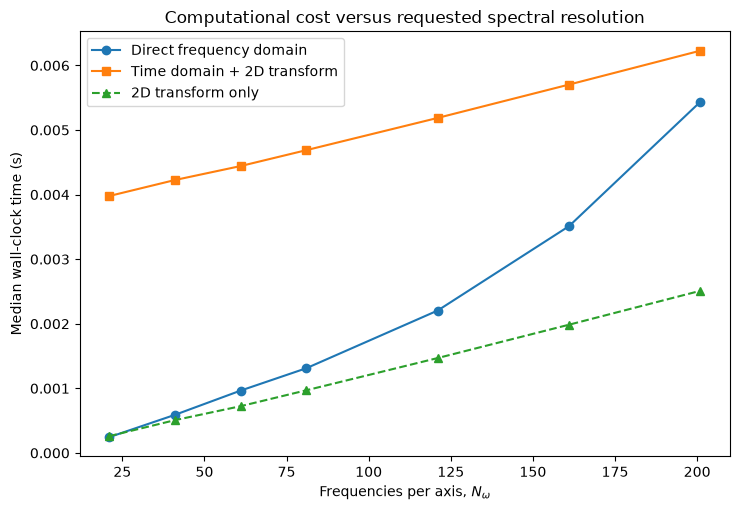

In [59]:
# ------------------------------------------------------------
# Benchmark 3 figure: runtime scaling
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 5.2),
)

ax.plot(
    Nw_scan,
    FD_scaling_times,
    marker="o",
    label="Direct frequency domain",
)

ax.plot(
    Nw_scan,
    TD_total_refined,
    marker="s",
    label="Time domain + 2D transform",
)

ax.plot(
    Nw_scan,
    TD_transform_scaling,
    marker="^",
    linestyle="--",
    label="2D transform only",
)

ax.set_xlabel(
    r"Frequencies per axis, $N_\omega$"
)

ax.set_ylabel(
    "Median wall-clock time (s)"
)

ax.set_title(
    "Computational cost versus requested spectral resolution"
)

ax.legend()

plt.tight_layout()

png_path = (
    figure_dir
    / "runtime_scaling_vs_spectral_resolution.png"
)

pdf_path = (
    figure_dir
    / "runtime_scaling_vs_spectral_resolution.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

Saved:
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/FD_speedup_vs_spectral_resolution.png
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/FD_speedup_vs_spectral_resolution.pdf


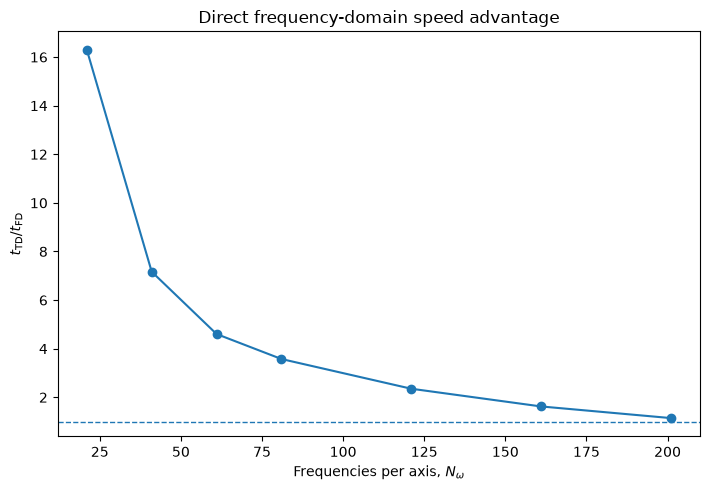

In [60]:
# ------------------------------------------------------------
# Benchmark 3 figure: FD speed advantage
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 5.0),
)

ax.plot(
    Nw_scan,
    speedup_refined,
    marker="o",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    r"Frequencies per axis, $N_\omega$"
)

ax.set_ylabel(
    r"$t_{\mathrm{TD}}/t_{\mathrm{FD}}$"
)

ax.set_title(
    "Direct frequency-domain speed advantage"
)

plt.tight_layout()

png_path = (
    figure_dir
    / "FD_speedup_vs_spectral_resolution.png"
)

pdf_path = (
    figure_dir
    / "FD_speedup_vs_spectral_resolution.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

print("Saved:")
print(png_path)
print(pdf_path)

plt.show()

In [61]:
# ------------------------------------------------------------
# Save Benchmarks 1-3
# ------------------------------------------------------------

np.savez(
    figure_dir / "notebook05_benchmarks_1_to_3.npz",

    # Benchmark 1
    benchmark1_fd_time=t_FD_batch,
    benchmark1_td_propagation=t_TD_prop_batch,
    benchmark1_td_transform=t_TD_fft_batch,
    benchmark1_td_total=t_TD_total_batch,
    benchmark1_speedup=speedup_batch,

    # Benchmark 2
    benchmark2_impulsive=t_impulsive,
    benchmark2_short=t_short,
    benchmark2_finite=t_finite_refined,

    # Benchmark 3
    Nw_scan=Nw_scan,
    FD_scaling_times=FD_scaling_times,
    TD_transform_scaling=TD_transform_scaling,
    TD_total_refined=TD_total_refined,
    speedup_refined=speedup_refined,
)

print(
    "Saved:",
    figure_dir / "notebook05_benchmarks_1_to_3.npz"
)

Saved: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/notebook05_benchmarks_1_to_3.npz


## 4. Comparison with QuDPy

As an external implementation benchmark, the impulsive nonrephasing
RWA response is also calculated using QuDPy.

QuDPy evaluates nonlinear optical response functions by explicit
time-domain propagation of double-sided Liouville pathways. For the
nonrephasing branch, the three contributing pathways are

\[
R_4,\qquad R_5,\qquad R_6,
\]

and the complete response is

\[
R_{\mathrm{NR}}^{(3)}
=
i\left(
R_4-R_5-R_6
\right).
\]

The comparison uses the same dimer Hamiltonian, collapse operators,
ground-state preparation, waiting time, coherence-time window, and
frequency-domain transform convention used in the direct resolvent
benchmark.

QuDPy propagation time and Fourier-transform time are recorded
separately.

In [62]:
import sys
from pathlib import Path

QUDPY_ROOT = Path(
    "/Users/alfonsocastillogonzalez/Desktop/Research/"
    "Spectroscopy_proyect/QuDPy"
)

assert (
    QUDPY_ROOT
    / "qudpy"
    / "__init__.py"
).exists()

if str(QUDPY_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(QUDPY_ROOT),
    )

import qudpy
import qutip

print("Python:", sys.executable)
print("QuTiP:", qutip.__version__)
print("QuDPy:", qudpy.__file__)

Python: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/QuDPy/.venv/bin/python
QuTiP: 5.3.1
QuDPy: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/QuDPy/qudpy/__init__.py


In [63]:
# ------------------------------------------------------------
# Build the same dimer in QuDPy
# ------------------------------------------------------------

H_q = qutip.Qobj(
    model["H_S"]
)

rho0_q = qutip.Qobj(
    model["rho0"]
)

mu_q = qutip.Qobj(
    model["mu"]
)

a_q = qutip.Qobj(
    model["sigma_a_minus"]
    + model["sigma_b_minus"]
)

c_ops_q = [
    qutip.Qobj(model["L_a_down"]),
    qutip.Qobj(model["L_a_up"]),
    qutip.Qobj(model["L_b_down"]),
    qutip.Qobj(model["L_b_up"]),
]

qudpy_system = System(
    H=H_q,
    rho=rho0_q,
    a=a_q,
    u=mu_q,
    c_ops=c_ops_q,
    diagonalize=False,
)

print("QuDPy system constructed.")
print("H shape:", H_q.shape)
print("rho shape:", rho0_q.shape)
print("collapse operators:", len(c_ops_q))

system initialized
QuDPy system constructed.
H shape: (4, 4)
rho shape: (4, 4)
collapse operators: 4


In [72]:
# ------------------------------------------------------------
# Generate the exact QuDPy pathways using UFSS
# ------------------------------------------------------------

import ufss

DG = ufss.DiagramGenerator
R3rd = DG()

t_pulse = np.array([
    -1,
    +1,
])

R3rd.efield_times = [
    t_pulse,
    t_pulse,
    t_pulse,
    t_pulse,
]


# ------------------------------------------------------------
# Rephasing: (-,+,+)
# Included so that we reproduce the original workflow exactly.
# ------------------------------------------------------------

R3rd.set_phase_discrimination([
    (0, 1),
    (1, 0),
    (1, 0),
])

[
    R3_diagram,
    R1_diagram,
    R2_diagram,
] = R3rd.get_diagrams([
    0,
    100,
    200,
    300,
])


# ------------------------------------------------------------
# Nonrephasing: (+,-,+)
# ------------------------------------------------------------

R3rd.set_phase_discrimination([
    (1, 0),
    (0, 1),
    (1, 0),
])

[
    R6_diagram,
    R4_diagram,
    R5_diagram,
] = R3rd.get_diagrams([
    0,
    100,
    200,
    300,
])


print("Nonrephasing diagrams")
print("---------------------")

print("R4 =", R4_diagram)
print("R5 =", R5_diagram)
print("R6 =", R6_diagram)

Nonrephasing diagrams
---------------------
R4 = (('Ku', 0), ('Bu', 1), ('Ku', 2))
R5 = (('Ku', 0), ('Bu', 1), ('Bd', 2))
R6 = (('Ku', 0), ('Kd', 1), ('Ku', 2))


In [73]:
# ------------------------------------------------------------
# QuDPy benchmark parameters
# ------------------------------------------------------------

qudpy_time_delays = [
    tmax_bench,
    T_bench,
    tmax_bench,
]

qudpy_scan_id = [
    0,
    2,
]

qudpy_resolution = 4


def run_qudpy_pathway(
    diagram,
    parallel=False,
):
    gc.collect()

    t0 = perf_counter()

    _, tq1, tq3, D = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=parallel,
        )
    )

    t1 = perf_counter()

    return (
        np.asarray(tq1, dtype=float),
        np.asarray(tq3, dtype=float),
        np.asarray(D, dtype=complex),
        t1 - t0,
    )

In [74]:
# ------------------------------------------------------------
# Run UFSS-generated nonrephasing pathways
# ------------------------------------------------------------

print("Running R4...")
tq1_4, tq3_4, D4, t_R4 = run_qudpy_pathway(
    R4_diagram,
    parallel=False,
)

print()
print("Running R5...")
tq1_5, tq3_5, D5, t_R5 = run_qudpy_pathway(
    R5_diagram,
    parallel=False,
)

print()
print("Running R6...")
tq1_6, tq3_6, D6, t_R6 = run_qudpy_pathway(
    R6_diagram,
    parallel=False,
)

t_qudpy_prop = (
    t_R4
    + t_R5
    + t_R6
)

print()
print("QUDPY NR PROPAGATION")
print("--------------------")
print()

print(f"R4 = {t_R4:.6f} s")
print(f"R5 = {t_R5:.6f} s")
print(f"R6 = {t_R6:.6f} s")

print()

print(f"Total = {t_qudpy_prop:.6f} s")

print()
print("t1 points =", len(tq1_4))
print("t3 points =", len(tq3_4))
print("dt1 =", tq1_4[1] - tq1_4[0])
print("dt3 =", tq3_4[1] - tq3_4[0])

Running R4...
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

Running R5...
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

Running R6...
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

QUDPY NR PROPAGATION
--------------------

R4 = 1.548891 s
R5 = 1.594277 s
R6 = 1.585719 s

Total = 4.728888 s

t1 points = 400
t3 points = 400
dt1 = 0.2506265664160401
dt3 = 0.2506265664160401


In [75]:
# ------------------------------------------------------------
# Assemble QuDPy NR response and test orientation
# ------------------------------------------------------------

NR_qudpy_raw = (
    1j
    * (
        D4
        - D5
        - D6
    )
)


P_NR_fd_reference = direct_NR_frequency_domain(
    omega1_bench,
    omega3_bench,
    T_bench,
    eta_bench,
)


# Raw QuDPy array
P_qudpy_raw = damped_2D_transform(
    NR_qudpy_raw,
    tq1_4,
    tq3_4,
    omega1_bench,
    omega3_bench,
    eta_bench,
)


# Transposed QuDPy array
P_qudpy_transposed = damped_2D_transform(
    NR_qudpy_raw.T,
    tq1_4,
    tq3_4,
    omega1_bench,
    omega3_bench,
    eta_bench,
)


error_raw = (
    np.linalg.norm(
        P_qudpy_raw
        - P_NR_fd_reference
    )
    /
    np.linalg.norm(
        P_NR_fd_reference
    )
)


error_transposed = (
    np.linalg.norm(
        P_qudpy_transposed
        - P_NR_fd_reference
    )
    /
    np.linalg.norm(
        P_NR_fd_reference
    )
)


print("QUDPY ORIENTATION TEST")
print("----------------------")
print()

print(
    f"Raw orientation error        = "
    f"{100*error_raw:.4f}%"
)

print(
    f"Transposed orientation error = "
    f"{100*error_transposed:.4f}%"
)

QUDPY ORIENTATION TEST
----------------------

Raw orientation error        = 49.8306%
Transposed orientation error = 1.4538%


In [76]:
# ------------------------------------------------------------
# Select correct QuDPy orientation
# ------------------------------------------------------------

if error_raw <= error_transposed:

    R_NR_qudpy = NR_qudpy_raw
    P_NR_qudpy = P_qudpy_raw

    print("Selected: raw QuDPy orientation")

else:

    R_NR_qudpy = NR_qudpy_raw.T
    P_NR_qudpy = P_qudpy_transposed

    print("Selected: transposed QuDPy orientation")

Selected: transposed QuDPy orientation


In [77]:
# ------------------------------------------------------------
# Corrected QuDPy validation
# ------------------------------------------------------------

qudpy_raw_error = (
    np.linalg.norm(
        P_NR_qudpy
        - P_NR_fd_reference
    )
    /
    np.linalg.norm(
        P_NR_fd_reference
    )
)


alpha_qudpy = (
    np.vdot(
        P_NR_qudpy,
        P_NR_fd_reference,
    )
    /
    np.vdot(
        P_NR_qudpy,
        P_NR_qudpy,
    )
)


qudpy_shape_error = (
    np.linalg.norm(
        alpha_qudpy
        * P_NR_qudpy
        - P_NR_fd_reference
    )
    /
    np.linalg.norm(
        P_NR_fd_reference
    )
)


print()
print("CORRECTED QUDPY VALIDATION")
print("--------------------------")
print()

print(
    f"Raw relative error = "
    f"{100*qudpy_raw_error:.4f}%"
)

print(
    "alpha =",
    alpha_qudpy,
)

print(
    f"Shape error        = "
    f"{100*qudpy_shape_error:.4f}%"
)


CORRECTED QUDPY VALIDATION
--------------------------

Raw relative error = 1.4538%
alpha = (0.9924212691669543-0.001924357744138703j)
Shape error        = 1.2218%


In [78]:
# ------------------------------------------------------------
# Final Benchmark 1 timing in common environment
# ------------------------------------------------------------

_, t_FD_final, times_FD_final = benchmark_batched(
    direct_NR_frequency_domain,
    omega1_bench,
    omega3_bench,
    T_bench,
    eta_bench,
    batch_size=50,
    repeats=7,
    warmup=2,
)

_, t_TD_prop_final, times_TD_prop_final = benchmark_batched(
    NR_time_domain_response,
    t1_bench,
    t3_bench,
    T_bench,
    batch_size=10,
    repeats=7,
    warmup=2,
)

R_final = NR_time_domain_response(
    t1_bench,
    t3_bench,
    T_bench,
)

_, t_TD_ft_final, times_TD_ft_final = benchmark_batched(
    damped_2D_transform,
    R_final,
    t1_bench,
    t3_bench,
    omega1_bench,
    omega3_bench,
    eta_bench,
    batch_size=50,
    repeats=7,
    warmup=2,
)

t_TD_total_final = (
    t_TD_prop_final
    + t_TD_ft_final
)

speedup_final = (
    t_TD_total_final
    / t_FD_final
)

print("FINAL BENCHMARK 1")
print("-----------------")
print()

print(f"Direct FD      = {t_FD_final:.6f} s")
print(f"TD propagation = {t_TD_prop_final:.6f} s")
print(f"2D transform   = {t_TD_ft_final:.6f} s")
print(f"TD total       = {t_TD_total_final:.6f} s")

print()
print(f"TD / FD        = {speedup_final:.3f} x")

print()
print("FD timings =", times_FD_final)
print("TD timings =", times_TD_prop_final)
print("FT timings =", times_TD_ft_final)

FINAL BENCHMARK 1
-----------------

Direct FD      = 0.001298 s
TD propagation = 0.003726 s
2D transform   = 0.000934 s
TD total       = 0.004660 s

TD / FD        = 3.591 x

FD timings = [0.00141763 0.0013062  0.0012982  0.00129772 0.00129511 0.00129453
 0.00125625]
TD timings = [0.00374705 0.00372224 0.00372695 0.00371138 0.00373675 0.00370982
 0.0037255 ]
FT timings = [0.00095267 0.00093828 0.00093426 0.00092876 0.00092603 0.00093563
 0.00092906]


In [79]:
# ------------------------------------------------------------
# Final Benchmark 2 timing in common environment
# ------------------------------------------------------------

_, t_impulsive_final, _ = benchmark_batched(
    impulsive_NR_RWA_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    batch_size=50,
    repeats=7,
    warmup=2,
)

_, t_short_final, _ = benchmark_batched(
    short_NR_RWA_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
    batch_size=50,
    repeats=7,
    warmup=2,
)

_, t_finite_final, finite_samples_final = benchmark_batched(
    finite_NR_fullV_stationary,
    omega1_bench,
    omega3_bench,
    T_pulse_bench,
    eta_bench,
    sigma_pulse,
    batch_size=10,
    repeats=7,
    warmup=2,
)

print("FINAL BENCHMARK 2")
print("-----------------")
print()

print(f"Impulsive RWA      = {t_impulsive_final:.6f} s")
print(f"Short-pulse RWA    = {t_short_final:.6f} s")
print(f"Finite-width fullV = {t_finite_final:.6f} s")

print()

print(
    f"Short / impulsive  = "
    f"{t_short_final/t_impulsive_final:.3f} x"
)

print(
    f"Finite / short     = "
    f"{t_finite_final/t_short_final:.3f} x"
)

print(
    f"Finite / impulsive = "
    f"{t_finite_final/t_impulsive_final:.3f} x"
)

FINAL BENCHMARK 2
-----------------

Impulsive RWA      = 0.001299 s
Short-pulse RWA    = 0.001334 s
Finite-width fullV = 0.007336 s

Short / impulsive  = 1.027 x
Finite / short     = 5.501 x
Finite / impulsive = 5.647 x


In [80]:
# ------------------------------------------------------------
# Final Benchmark 3: requested frequency-grid density
# ------------------------------------------------------------

Nw_scan = np.array([
    21,
    41,
    61,
    81,
    121,
    161,
    201,
])

FD_scaling_final = []
FT_scaling_final = []


# Time-domain response is independent of Nw.
R_scaling_final = NR_time_domain_response(
    t1_bench,
    t3_bench,
    T_bench,
)


for Nw in Nw_scan:

    print(
        f"Nw = {Nw}"
    )

    omega1_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    omega3_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )


    # Direct frequency-domain calculation
    _, t_fd, _ = benchmark_batched(
        direct_NR_frequency_domain,
        omega1_test,
        omega3_test,
        T_bench,
        eta_bench,
        batch_size=20,
        repeats=7,
        warmup=2,
    )


    # Transform of the already-propagated TD response
    _, t_ft, _ = benchmark_batched(
        damped_2D_transform,
        R_scaling_final,
        t1_bench,
        t3_bench,
        omega1_test,
        omega3_test,
        eta_bench,
        batch_size=20,
        repeats=7,
        warmup=2,
    )


    FD_scaling_final.append(
        t_fd
    )

    FT_scaling_final.append(
        t_ft
    )


FD_scaling_final = np.asarray(
    FD_scaling_final
)

FT_scaling_final = np.asarray(
    FT_scaling_final
)


TD_total_scaling_final = (
    t_TD_prop_final
    + FT_scaling_final
)

speedup_scaling_final = (
    TD_total_scaling_final
    / FD_scaling_final
)

Nw = 21
Nw = 41
Nw = 61
Nw = 81
Nw = 121
Nw = 161
Nw = 201


In [81]:
print()
print("FINAL BENCHMARK 3")
print("-----------------")
print()

print(
    " Nw    points     FD [s]    TD prop [s]   FT [s]    TD total [s]   TD/FD"
)

print(
    "----------------------------------------------------------------------------"
)

for (
    Nw,
    t_fd,
    t_ft,
    t_total,
    ratio,
) in zip(
    Nw_scan,
    FD_scaling_final,
    FT_scaling_final,
    TD_total_scaling_final,
    speedup_scaling_final,
):

    print(
        f"{Nw:4d}  "
        f"{Nw**2:8d}  "
        f"{t_fd:9.6f}  "
        f"{t_TD_prop_final:11.6f}  "
        f"{t_ft:8.6f}  "
        f"{t_total:12.6f}  "
        f"{ratio:7.3f}"
    )


FINAL BENCHMARK 3
-----------------

 Nw    points     FD [s]    TD prop [s]   FT [s]    TD total [s]   TD/FD
----------------------------------------------------------------------------
  21       441   0.000244     0.003726  0.000274      0.003999   16.398
  41      1681   0.000586     0.003726  0.000489      0.004214    7.196
  61      3721   0.000954     0.003726  0.000684      0.004410    4.622
  81      6561   0.001303     0.003726  0.000969      0.004695    3.603
 121     14641   0.002213     0.003726  0.001421      0.005147    2.326
 161     25921   0.003548     0.003726  0.001944      0.005669    1.598
 201     40401   0.005160     0.003726  0.002487      0.006213    1.204


In [82]:
# ------------------------------------------------------------
# Complete QuDPy NR calculation for timing
# ------------------------------------------------------------

def complete_qudpy_NR():

    _, _, _, D4 = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=R4_diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=False,
        )
    )

    _, _, _, D5 = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=R5_diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=False,
        )
    )

    _, _, _, D6 = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=R6_diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=False,
        )
    )

    R_NR = (
        1j
        * (
            np.asarray(D4)
            - np.asarray(D5)
            - np.asarray(D6)
        )
    ).T

    return R_NR

In [83]:
# ------------------------------------------------------------
# Robust QuDPy timing
# ------------------------------------------------------------

qudpy_times = []

R_NR_qudpy_final = None


for k in range(3):

    print()
    print(
        f"QuDPy repetition {k + 1}/3"
    )

    gc.collect()

    t0 = perf_counter()

    R_NR_qudpy_final = (
        complete_qudpy_NR()
    )

    t1 = perf_counter()

    qudpy_times.append(
        t1 - t0
    )


qudpy_times = np.asarray(
    qudpy_times
)

t_qudpy_prop_final = np.median(
    qudpy_times
)


print()
print("FINAL QUDPY PROPAGATION TIMING")
print("------------------------------")
print()

print(
    "Individual times =",
    qudpy_times,
)

print(
    f"Median = "
    f"{t_qudpy_prop_final:.6f} s"
)


QuDPy repetition 1/3
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

QuDPy repetition 2/3
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

QuDPy repetition 3/3
First scan done, starting second scan. Remaining time = First Scan Time x nu

In [84]:
# ------------------------------------------------------------
# Final QuDPy transform timing
# ------------------------------------------------------------

P_NR_qudpy_final, t_qudpy_ft_final, qudpy_ft_samples_final = (
    benchmark_batched(
        damped_2D_transform,
        R_NR_qudpy_final,
        tq1_4,
        tq3_4,
        omega1_bench,
        omega3_bench,
        eta_bench,
        batch_size=50,
        repeats=7,
        warmup=2,
    )
)


t_qudpy_total_final = (
    t_qudpy_prop_final
    + t_qudpy_ft_final
)


print()
print("FINAL QUDPY TIMING")
print("------------------")
print()

print(
    f"Propagation = "
    f"{t_qudpy_prop_final:.6f} s"
)

print(
    f"Transform   = "
    f"{t_qudpy_ft_final:.6f} s"
)

print(
    f"Total       = "
    f"{t_qudpy_total_final:.6f} s"
)

print()

print(
    f"QuDPy / direct FD = "
    f"{t_qudpy_total_final/t_FD_final:.1f} x"
)

print(
    f"QuDPy / our TD    = "
    f"{t_qudpy_total_final/t_TD_total_final:.1f} x"
)


FINAL QUDPY TIMING
------------------

Propagation = 4.788321 s
Transform   = 0.001011 s
Total       = 4.789332 s

QuDPy / direct FD = 3690.6 x
QuDPy / our TD    = 1027.8 x


In [85]:
# ------------------------------------------------------------
# QuDPy parallel timing
# ------------------------------------------------------------

def complete_qudpy_NR_parallel():

    _, _, _, D4 = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=R4_diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=True,
        )
    )

    _, _, _, D5 = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=R5_diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=True,
        )
    )

    _, _, _, D6 = (
        qudpy_system.coherence2d(
            time_delays=qudpy_time_delays,
            diagram=R6_diagram,
            scan_id=qudpy_scan_id,
            r=qudpy_resolution,
            parallel=True,
        )
    )

    return (
        1j
        * (
            np.asarray(D4)
            - np.asarray(D5)
            - np.asarray(D6)
        )
    ).T

In [86]:
qudpy_parallel_times = []

R_NR_qudpy_parallel = None

for k in range(3):

    print()
    print(
        f"Parallel QuDPy repetition {k + 1}/3"
    )

    gc.collect()

    t0 = perf_counter()

    R_NR_qudpy_parallel = (
        complete_qudpy_NR_parallel()
    )

    t1 = perf_counter()

    qudpy_parallel_times.append(
        t1 - t0
    )


qudpy_parallel_times = np.asarray(
    qudpy_parallel_times
)

t_qudpy_parallel = np.median(
    qudpy_parallel_times
)


print()
print("QUDPY PARALLEL TIMING")
print("---------------------")
print()

print(
    "Individual times =",
    qudpy_parallel_times,
)

print(
    f"Median = "
    f"{t_qudpy_parallel:.6f} s"
)

print()

print(
    f"Parallel QuDPy / FD = "
    f"{t_qudpy_parallel/t_FD_final:.1f} x"
)


Parallel QuDPy repetition 1/3
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

Parallel QuDPy repetition 2/3
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done

Parallel QuDPy repetition 3/3
First scan done, starting second scan. Remaining 

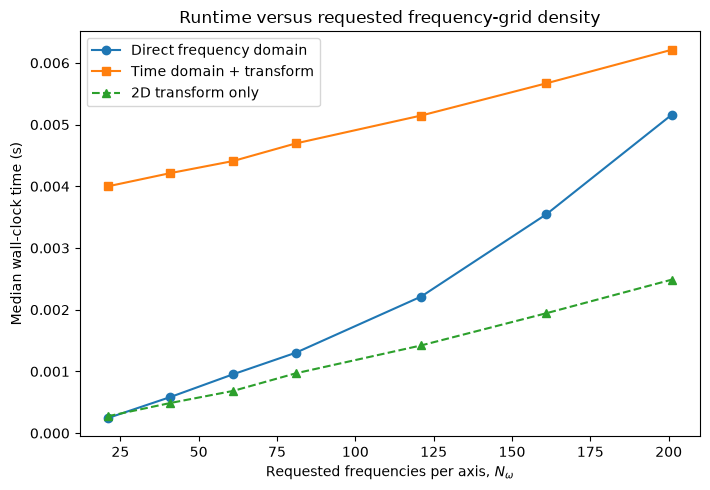

In [87]:
# ------------------------------------------------------------
# Final Figure 1:
# runtime versus requested frequency-grid density
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 5.0)
)

ax.plot(
    Nw_scan,
    FD_scaling_final,
    marker="o",
    label="Direct frequency domain",
)

ax.plot(
    Nw_scan,
    TD_total_scaling_final,
    marker="s",
    label="Time domain + transform",
)

ax.plot(
    Nw_scan,
    FT_scaling_final,
    marker="^",
    linestyle="--",
    label="2D transform only",
)

ax.set_xlabel(
    r"Requested frequencies per axis, $N_\omega$"
)

ax.set_ylabel(
    "Median wall-clock time (s)"
)

ax.set_title(
    "Runtime versus requested frequency-grid density"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    figure_dir
    / "runtime_vs_frequency_grid_density.pdf",
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "runtime_vs_frequency_grid_density.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [88]:
t_qudpy_parallel_total = (
    t_qudpy_parallel
    + t_qudpy_ft_final
)

print(
    "Parallel QuDPy total =",
    t_qudpy_parallel_total,
    "s",
)

print(
    "QuDPy / FD =",
    t_qudpy_parallel_total
    / t_FD_final,
)

print(
    "QuDPy / our TD =",
    t_qudpy_parallel_total
    / t_TD_total_final,
)

Parallel QuDPy total = 2.2439304879889823 s
QuDPy / FD = 1729.1385515560428
QuDPy / our TD = 481.55529390561816


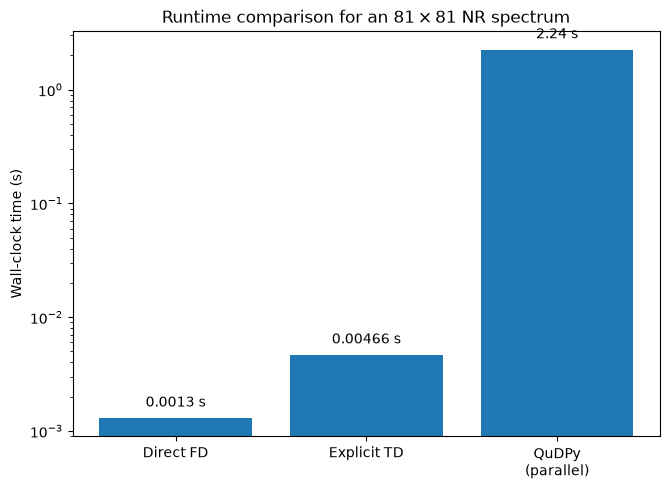

In [89]:
# ------------------------------------------------------------
# Final Figure 2:
# implementation-level runtime comparison
# ------------------------------------------------------------

runtime_labels = [
    "Direct FD",
    "Explicit TD",
    "QuDPy\n(parallel)",
]

runtime_values = np.array([
    t_FD_final,
    t_TD_total_final,
    t_qudpy_parallel_total,
])


fig, ax = plt.subplots(
    figsize=(6.8, 5.0)
)

bars = ax.bar(
    runtime_labels,
    runtime_values,
)

ax.set_yscale(
    "log"
)

ax.set_ylabel(
    "Wall-clock time (s)"
)

ax.set_title(
    r"Runtime comparison for an $81\times81$ NR spectrum"
)


for bar, value in zip(
    bars,
    runtime_values,
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        value * 1.18,
        f"{value:.3g} s",
        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.savefig(
    figure_dir
    / "FD_TD_QuDPy_runtime_comparison.pdf",
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "FD_TD_QuDPy_runtime_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [90]:
# ------------------------------------------------------------
# Save final Notebook 05 benchmark data
# ------------------------------------------------------------

np.savez(
    figure_dir
    / "notebook05_final_benchmarks.npz",

    # Benchmark 1
    fd_time=t_FD_final,
    td_propagation_time=t_TD_prop_final,
    td_transform_time=t_TD_ft_final,
    td_total_time=t_TD_total_final,
    td_over_fd=t_TD_total_final / t_FD_final,

    # Benchmark 2
    impulsive_rwa_time=t_impulsive_final,
    short_pulse_rwa_time=t_short_final,
    finite_width_fullV_time=t_finite_final,

    # Benchmark 3
    Nw_scan=Nw_scan,
    FD_scaling=FD_scaling_final,
    FT_scaling=FT_scaling_final,
    TD_total_scaling=TD_total_scaling_final,
    speedup_scaling=(
        TD_total_scaling_final
        / FD_scaling_final
    ),

    # Benchmark 4
    qudpy_serial_time=t_qudpy_prop_final,
    qudpy_parallel_times=qudpy_parallel_times,
    qudpy_parallel_time=t_qudpy_parallel,
    qudpy_transform_time=t_qudpy_ft_final,
    qudpy_parallel_total=t_qudpy_parallel_total,

    # QuDPy validation
    qudpy_raw_error=qudpy_raw_error,
    qudpy_shape_error=qudpy_shape_error,
    qudpy_alpha=alpha_qudpy,
)

print(
    "Saved:",
    figure_dir
    / "notebook05_final_benchmarks.npz"
)

Saved: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/notebook05_final_benchmarks.npz


In [91]:
# ------------------------------------------------------------
# Benchmark environment metadata
# ------------------------------------------------------------

import platform
import os
import scipy

print("BENCHMARK ENVIRONMENT")
print("---------------------")
print()

print("Python:", platform.python_version())
print("Python executable:", sys.executable)
print("Platform:", platform.platform())
print("Machine:", platform.machine())
print("Logical CPUs:", os.cpu_count())

print()

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("QuTiP:", qutip.__version__)
print("QuDPy:", qudpy.__file__)

BENCHMARK ENVIRONMENT
---------------------

Python: 3.13.9
Python executable: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/QuDPy/.venv/bin/python
Platform: macOS-26.6-arm64-arm-64bit-Mach-O
Machine: arm64
Logical CPUs: 10

NumPy: 2.5.2
SciPy: 1.18.1
QuTiP: 5.3.1
QuDPy: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/QuDPy/qudpy/__init__.py


In [92]:
# ------------------------------------------------------------
# Extended frequency-grid scan near and beyond crossover
# ------------------------------------------------------------

Nw_extended = np.array([
    201,
    221,
    241,
    261,
    301,
    351,
    401,
])

FD_extended = []
FT_extended = []


for Nw in Nw_extended:

    print(f"Nw = {Nw}")

    omega1_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    omega3_test = np.linspace(
        0.6,
        1.4,
        Nw,
    )

    _, t_fd, _ = benchmark_batched(
        direct_NR_frequency_domain,
        omega1_test,
        omega3_test,
        T_bench,
        eta_bench,
        batch_size=10,
        repeats=5,
        warmup=2,
    )

    _, t_ft, _ = benchmark_batched(
        damped_2D_transform,
        R_scaling_final,
        t1_bench,
        t3_bench,
        omega1_test,
        omega3_test,
        eta_bench,
        batch_size=10,
        repeats=5,
        warmup=2,
    )

    FD_extended.append(t_fd)
    FT_extended.append(t_ft)


FD_extended = np.asarray(FD_extended)
FT_extended = np.asarray(FT_extended)

TD_extended = (
    t_TD_prop_final
    + FT_extended
)

ratio_extended = (
    TD_extended
    / FD_extended
)


print()
print("EXTENDED GRID SCAN")
print("------------------")
print()

print(
    " Nw       FD [s]       TD [s]       TD/FD"
)

print(
    "---------------------------------------------"
)

for Nw, t_fd, t_td, ratio in zip(
    Nw_extended,
    FD_extended,
    TD_extended,
    ratio_extended,
):

    print(
        f"{Nw:4d}   "
        f"{t_fd:10.6f}   "
        f"{t_td:10.6f}   "
        f"{ratio:8.3f}"
    )

Nw = 201
Nw = 221
Nw = 241
Nw = 261
Nw = 301
Nw = 351
Nw = 401

EXTENDED GRID SCAN
------------------

 Nw       FD [s]       TD [s]       TD/FD
---------------------------------------------
 201     0.005226     0.006221      1.190
 221     0.006074     0.006442      1.061
 241     0.006374     0.006769      1.062
 261     0.007743     0.007347      0.949
 301     0.010071     0.007925      0.787
 351     0.013121     0.008981      0.684
 401     0.017829     0.009758      0.547


The parameter \(N_\omega\) denotes the number of requested frequency
samples along each spectral axis. The resulting two-dimensional
spectrum therefore contains

\[
N_\omega^2
\]

complex spectral points. For example, \(N_\omega=201\) corresponds to
a \(201\times201\) spectrum containing \(40\,401\) spectral pixels.

## 4. Scaling with the coherence-time window

Increasing the number of requested frequency samples \(N_\omega\)
does not by itself improve the intrinsic Fourier resolution of a
time-domain calculation.

For a fixed temporal spacing \(\Delta t\), finer Fourier resolution
requires a longer coherence-time window. The nominal frequency spacing
associated with a time window \(t_{\max}\) scales as

\[
\Delta\omega_{\mathrm{FT}}
\sim
\frac{2\pi}{t_{\max}}.
\]

For equal \(t_1\) and \(t_3\) grids, the number of propagated
time-domain samples is

\[
N_t
=
\frac{t_{\max}}{\Delta t}+1,
\]

and the two-dimensional response contains

\[
N_t^2
\]

complex time-domain points.

The following benchmark therefore increases \(t_{\max}\) while keeping
\(\Delta t\), the molecular model, the damping parameter, and the final
\(81\times81\) frequency grid fixed.

The direct frequency-domain result requires no coherence-time
propagation and therefore provides the reference spectrum independently
of \(t_{\max}\).

In [93]:
# ------------------------------------------------------------
# Benchmark 4:
# scaling with the coherence-time window
# ------------------------------------------------------------

tmax_scan = np.array([
    25.0,
    50.0,
    75.0,
    100.0,
    150.0,
    200.0,
    300.0,
    400.0,
])

dt_resolution = 0.25


# Keep the requested spectral grid fixed.
omega1_resolution = omega1_bench
omega3_resolution = omega3_bench


# Exact direct-FD reference on this grid.
P_FD_resolution = direct_NR_frequency_domain(
    omega1_resolution,
    omega3_resolution,
    T_bench,
    eta_bench,
)


Nt_resolution = []
td_pixels_resolution = []
delta_omega_nominal = []

TD_prop_resolution = []
TD_ft_resolution = []
TD_total_resolution = []

TD_error_resolution = []

In [94]:
# ------------------------------------------------------------
# Run time-window scan
# ------------------------------------------------------------

for tmax_test in tmax_scan:

    print()
    print(
        f"tmax = {tmax_test:.1f}"
    )

    t1_test = np.arange(
        0.0,
        tmax_test + 0.5 * dt_resolution,
        dt_resolution,
    )

    t3_test = t1_test.copy()

    Nt = len(t1_test)


    # --------------------------------------------------------
    # TD propagation
    # --------------------------------------------------------

    R_test, t_prop, _ = benchmark_batched(
        NR_time_domain_response,
        t1_test,
        t3_test,
        T_bench,
        batch_size=1,
        repeats=3,
        warmup=1,
    )


    # --------------------------------------------------------
    # TD transform
    # --------------------------------------------------------

    P_TD_test, t_ft, _ = benchmark_batched(
        damped_2D_transform,
        R_test,
        t1_test,
        t3_test,
        omega1_resolution,
        omega3_resolution,
        eta_bench,
        batch_size=1,
        repeats=3,
        warmup=1,
    )


    # --------------------------------------------------------
    # Accuracy relative to direct resolvent
    # --------------------------------------------------------

    rel_error = (
        np.linalg.norm(
            P_TD_test
            - P_FD_resolution
        )
        /
        np.linalg.norm(
            P_FD_resolution
        )
    )


    Nt_resolution.append(
        Nt
    )

    td_pixels_resolution.append(
        Nt**2
    )

    delta_omega_nominal.append(
        2.0 * np.pi
        / tmax_test
    )

    TD_prop_resolution.append(
        t_prop
    )

    TD_ft_resolution.append(
        t_ft
    )

    TD_total_resolution.append(
        t_prop + t_ft
    )

    TD_error_resolution.append(
        rel_error
    )


tmax = 25.0

tmax = 50.0

tmax = 75.0

tmax = 100.0

tmax = 150.0

tmax = 200.0

tmax = 300.0

tmax = 400.0


In [95]:
Nt_resolution = np.asarray(
    Nt_resolution
)

td_pixels_resolution = np.asarray(
    td_pixels_resolution
)

delta_omega_nominal = np.asarray(
    delta_omega_nominal
)

TD_prop_resolution = np.asarray(
    TD_prop_resolution
)

TD_ft_resolution = np.asarray(
    TD_ft_resolution
)

TD_total_resolution = np.asarray(
    TD_total_resolution
)

TD_error_resolution = np.asarray(
    TD_error_resolution
)

In [96]:
print()
print("TIME-WINDOW / RESOLUTION BENCHMARK")
print("----------------------------------")
print()

print(
    " tmax    Nt      Nt^2       dw_nom      TD prop     FT        TD total    error"
)

print(
    "--------------------------------------------------------------------------------"
)

for (
    tmax_test,
    Nt,
    pixels,
    dw,
    t_prop,
    t_ft,
    t_total,
    error,
) in zip(
    tmax_scan,
    Nt_resolution,
    td_pixels_resolution,
    delta_omega_nominal,
    TD_prop_resolution,
    TD_ft_resolution,
    TD_total_resolution,
    TD_error_resolution,
):

    print(
        f"{tmax_test:5.0f}  "
        f"{Nt:5d}  "
        f"{pixels:9d}  "
        f"{dw:10.5f}  "
        f"{t_prop:10.6f}  "
        f"{t_ft:8.6f}  "
        f"{t_total:10.6f}  "
        f"{100*error:7.3f}%"
    )


TIME-WINDOW / RESOLUTION BENCHMARK
----------------------------------

 tmax    Nt      Nt^2       dw_nom      TD prop     FT        TD total    error
--------------------------------------------------------------------------------
   25    101      10201     0.25133    0.000771  0.000236    0.001008   40.900%
   50    201      40401     0.12566    0.001439  0.000634    0.002074   12.341%
   75    301      90601     0.08378    0.002354  0.000832    0.003186    3.655%
  100    401     160801     0.06283    0.003743  0.001179    0.004922    1.079%
  150    601     361201     0.04189    0.007707  0.001978    0.009685    0.098%
  200    801     641601     0.03142    0.012208  0.002961    0.015169    0.030%
  300   1201    1442401     0.02094    0.025819  0.005456    0.031274    0.029%
  400   1601    2563201     0.01571    0.043265  0.008225    0.051489    0.029%


In [97]:
resolution_speed_ratio = (
    TD_total_resolution
    / t_FD_final
)


print()
print("TD / FD versus time window")
print("--------------------------")

for tmax_test, ratio in zip(
    tmax_scan,
    resolution_speed_ratio,
):

    print(
        f"tmax = {tmax_test:5.0f} : "
        f"{ratio:8.3f} x"
    )


TD / FD versus time window
--------------------------
tmax =    25 :    0.777 x
tmax =    50 :    1.598 x
tmax =    75 :    2.455 x
tmax =   100 :    3.793 x
tmax =   150 :    7.463 x
tmax =   200 :   11.689 x
tmax =   300 :   24.100 x
tmax =   400 :   39.677 x


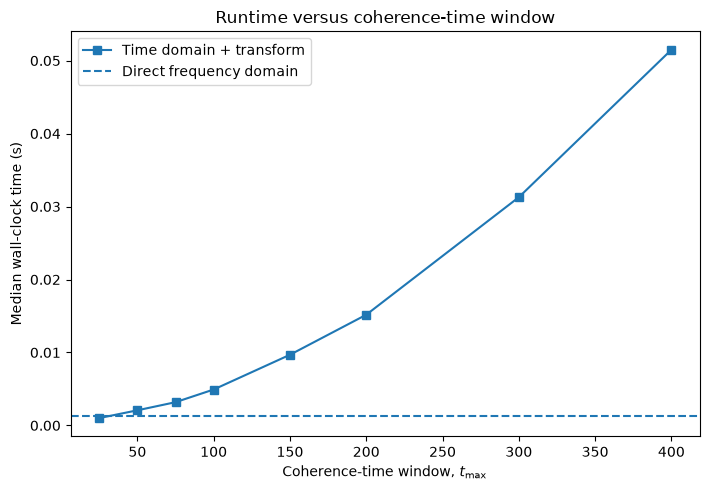

In [98]:
fig, ax = plt.subplots(
    figsize=(7.2, 5.0)
)

ax.plot(
    tmax_scan,
    TD_total_resolution,
    marker="s",
    label="Time domain + transform",
)

ax.axhline(
    t_FD_final,
    linestyle="--",
    label="Direct frequency domain",
)

ax.set_xlabel(
    r"Coherence-time window, $t_{\max}$"
)

ax.set_ylabel(
    "Median wall-clock time (s)"
)

ax.set_title(
    "Runtime versus coherence-time window"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    figure_dir
    / "runtime_vs_time_window.pdf",
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "runtime_vs_time_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

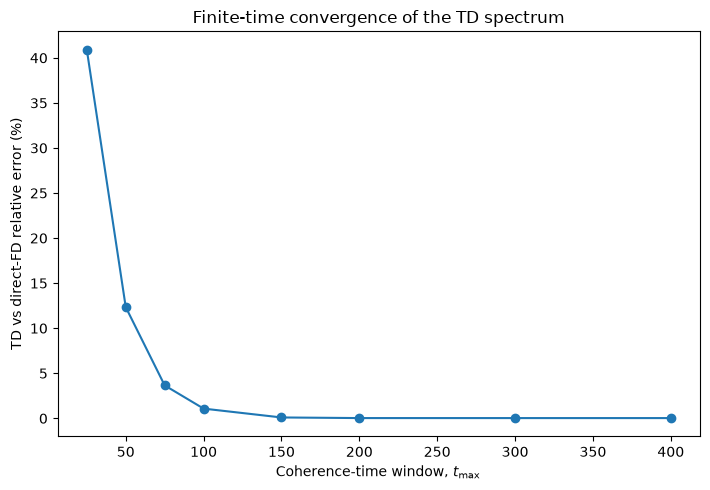

In [99]:
fig, ax = plt.subplots(
    figsize=(7.2, 5.0)
)

ax.plot(
    tmax_scan,
    100.0 * TD_error_resolution,
    marker="o",
)

ax.set_xlabel(
    r"Coherence-time window, $t_{\max}$"
)

ax.set_ylabel(
    "TD vs direct-FD relative error (%)"
)

ax.set_title(
    "Finite-time convergence of the TD spectrum"
)

plt.tight_layout()

plt.savefig(
    figure_dir
    / "TD_error_vs_time_window.pdf",
    bbox_inches="tight",
)

plt.savefig(
    figure_dir
    / "TD_error_vs_time_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Temporal-discretization convergence

For sufficiently long coherence-time windows, further increasing
\(t_{\max}\) no longer improves agreement with the direct resolvent.
The remaining discrepancy is therefore tested against the temporal
spacing \(\Delta t\).

The coherence-time window is fixed at \(t_{\max}=200\), where
finite-window truncation is already negligible, while the temporal
grid is progressively refined.

In [100]:
# ------------------------------------------------------------
# Temporal-discretization convergence
# ------------------------------------------------------------

dt_scan = np.array([
    0.5,
    0.25,
    0.125,
    0.0625,
])

tmax_dt_test = 200.0

Nt_dt = []
TD_dt_runtime = []
TD_dt_error = []


for dt_test in dt_scan:

    print()
    print(
        f"dt = {dt_test}"
    )

    t1_test = np.arange(
        0.0,
        tmax_dt_test + 0.5 * dt_test,
        dt_test,
    )

    t3_test = t1_test.copy()

    Nt = len(t1_test)


    # Propagate once for the accuracy calculation.
    t0 = perf_counter()

    R_test = NR_time_domain_response(
        t1_test,
        t3_test,
        T_bench,
    )

    P_test = damped_2D_transform(
        R_test,
        t1_test,
        t3_test,
        omega1_bench,
        omega3_bench,
        eta_bench,
    )

    t1 = perf_counter()


    error = (
        np.linalg.norm(
            P_test
            - P_FD_resolution
        )
        /
        np.linalg.norm(
            P_FD_resolution
        )
    )


    Nt_dt.append(
        Nt
    )

    TD_dt_runtime.append(
        t1 - t0
    )

    TD_dt_error.append(
        error
    )


Nt_dt = np.asarray(
    Nt_dt
)

TD_dt_runtime = np.asarray(
    TD_dt_runtime
)

TD_dt_error = np.asarray(
    TD_dt_error
)


dt = 0.5

dt = 0.25

dt = 0.125

dt = 0.0625


In [101]:
print()
print("TEMPORAL-DISCRETIZATION CONVERGENCE")
print("-----------------------------------")
print()

print(
    "   dt       Nt        Nt^2        runtime [s]      error"
)

print(
    "------------------------------------------------------------"
)

for dt, Nt, runtime, error in zip(
    dt_scan,
    Nt_dt,
    TD_dt_runtime,
    TD_dt_error,
):

    print(
        f"{dt:7.4f}  "
        f"{Nt:6d}  "
        f"{Nt**2:10d}  "
        f"{runtime:13.6f}  "
        f"{100*error:9.5f}%"
    )


TEMPORAL-DISCRETIZATION CONVERGENCE
-----------------------------------

   dt       Nt        Nt^2        runtime [s]      error
------------------------------------------------------------
 0.5000     401      160801       0.019237    0.11662%
 0.2500     801      641601       0.026010    0.03020%
 0.1250    1601     2563201       0.058140    0.01096%
 0.0625    3201    10246401       0.226112    0.00840%


The time-domain calculation initially converges rapidly toward the
direct resolvent as the coherence-time window is extended. At
\(t_{\max}=100\), the relative discrepancy is approximately \(1.08\%\),
whereas at \(t_{\max}=150\) it falls below \(0.1\%\).

Beyond \(t_{\max}\approx200\), the discrepancy saturates near
\(0.03\%\), indicating that finite-window truncation is no longer the
dominant numerical error. The remaining discrepancy is instead
associated with the finite temporal spacing used in the numerical
quadrature.

Importantly, the final frequency-domain output remains fixed at
\(81\times81=6561\) spectral points throughout this benchmark. The
increasing time-domain cost results from the progressively larger
intermediate \(t_1\times t_3\) response grid required to converge the
Fourier transform.

### Convergence with temporal discretization

At fixed \(t_{\max}=200\), refinement of the temporal spacing further
reduces the discrepancy between the time-domain calculation and the
direct resolvent. The relative error decreases from approximately

\[
0.117\%
\]

at \(\Delta t=0.5\) to

\[
0.0302\%
\]

at \(\Delta t=0.25\), and subsequently to

\[
0.0084\%
\]

at \(\Delta t=0.0625\).

The approximately fourfold reduction obtained in the first refinement
is consistent with the second-order trapezoidal quadrature used for the
time-domain Fourier transformation. At finer temporal spacing the
convergence begins to saturate, indicating that residual finite-window
truncation and other numerical errors become comparable to the
quadrature error.

For \(\Delta t=0.0625\), the \(t_1\times t_3\) response contains

\[
3201^2 = 10\,246\,401
\]

complex time-domain samples, despite the final requested spectrum
containing only

\[
81^2 = 6561
\]

frequency-domain points. This illustrates the increasing intermediate
computational burden required to converge an explicit time-domain
calculation, whereas the direct resolvent evaluates the requested
frequency points without introducing a finite coherence-time window.

In [102]:
np.savez(
    figure_dir / "notebook05_convergence_benchmarks.npz",

    # Requested frequency-grid density
    Nw_scan=Nw_scan,
    FD_scaling=FD_scaling_final,
    FT_scaling=FT_scaling_final,
    TD_total_scaling=TD_total_scaling_final,

    # Extended grid-density crossover
    Nw_extended=Nw_extended,
    FD_extended=FD_extended,
    FT_extended=FT_extended,
    TD_extended=TD_extended,
    ratio_extended=ratio_extended,

    # Time-window convergence
    tmax_scan=tmax_scan,
    Nt_resolution=Nt_resolution,
    td_pixels_resolution=td_pixels_resolution,
    delta_omega_nominal=delta_omega_nominal,
    TD_prop_resolution=TD_prop_resolution,
    TD_ft_resolution=TD_ft_resolution,
    TD_total_resolution=TD_total_resolution,
    TD_error_resolution=TD_error_resolution,

    # Temporal-spacing convergence
    dt_scan=dt_scan,
    Nt_dt=Nt_dt,
    TD_dt_runtime=TD_dt_runtime,
    TD_dt_error=TD_dt_error,
)

print(
    "Saved:",
    figure_dir / "notebook05_convergence_benchmarks.npz"
)

Saved: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/05_computational_benchmarks/notebook05_convergence_benchmarks.npz
